In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('data/insurance_data_for_modeling.csv')

print("="*60)
print("PREDICTIVE MODELING FOR RISK-BASED PRICING")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

PREDICTIVE MODELING FOR RISK-BASED PRICING
Dataset shape: (10000, 25)
Columns: ['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'Loss_Ratio', 'Margin', 'YearMonth', 'AgeGroup']


In [2]:
# Select features for modeling
feature_cols = ['Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 
                'RiskScore', 'Deductible', 'NCD', 'PastClaims', 'CoverType', 
                'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode']

# Target variables
target_severity = 'TotalClaims'  # For policies with claims
target_claim = 'Claimed'  # Binary: 1 if claim occurred, 0 otherwise

print("="*60)
print("FEATURE SELECTION")
print("="*60)
print(f"Features: {feature_cols}")
print(f"Target (Severity): {target_severity}")
print(f"Target (Claim Probability): {target_claim}")

FEATURE SELECTION
Features: ['Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'Deductible', 'NCD', 'PastClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode']
Target (Severity): TotalClaims
Target (Claim Probability): Claimed


In [3]:
# Identify categorical columns
categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply label encoding
label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("\n✅ Categorical variables encoded")

Categorical columns to encode: ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake', 'VehicleModel']

✅ Categorical variables encoded


In [4]:
# Identify categorical columns
categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply label encoding
label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("\n✅ Categorical variables encoded")

Categorical columns to encode: ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake', 'VehicleModel']

✅ Categorical variables encoded


In [5]:
print("="*60)
print("MODEL 1: CLAIM SEVERITY PREDICTION")
print("="*60)

# Filter only policies with claims
df_claims = df_encoded[df_encoded['Claimed'] == 1].copy()
print(f"Policies with claims: {len(df_claims)}")

if len(df_claims) > 0:
    # Prepare features and target
    X_sev = df_claims[feature_cols]
    y_sev = df_claims[target_severity]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    
    # XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    
    # Compare models
    results = {
        "Model": ["Linear Regression", "Random Forest", "XGBoost"],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, y_pred_lr)),
            np.sqrt(mean_squared_error(y_test, y_pred_rf)),
            np.sqrt(mean_squared_error(y_test, y_pred_xgb))
        ],
        "R2": [
            r2_score(y_test, y_pred_lr),
            r2_score(y_test, y_pred_rf),
            r2_score(y_test, y_pred_xgb)
        ]
    }
    
    results_df = pd.DataFrame(results)
    print("\nModel Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Identify best model
    best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']
    print(f"\n🏆 Best Model: {best_model}")
    
else:
    print("No claims data available for severity modeling")

MODEL 1: CLAIM SEVERITY PREDICTION
Policies with claims: 1535

Model Performance Comparison:
            Model        RMSE       R2
Linear Regression 5262.687572 0.216947
    Random Forest 5330.682007 0.196582
          XGBoost 5864.884238 0.027489

🏆 Best Model: Linear Regression


In [6]:
print("="*60)
print("MODEL 2: CLAIM PROBABILITY PREDICTION")
print("="*60)

# Prepare features and target
X_prob = df_encoded[feature_cols]
y_prob = df_encoded[target_claim]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_prob, y_prob, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

# XGBoost Classifier
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_clf.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_clf.predict(X_test_scaled)

# Compare models
results_clf = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_clf_df = pd.DataFrame(results_clf)
print("\nModel Performance Comparison:")
print(results_clf_df.to_string(index=False))

# Identify best model
best_clf = results_clf_df.loc[results_clf_df['F1-Score'].idxmax(), 'Model']
print(f"\n🏆 Best Classification Model: {best_clf}")

MODEL 2: CLAIM PROBABILITY PREDICTION

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression     0.859   0.584746 0.228477  0.328571
      Random Forest     0.857   0.574074 0.205298  0.302439
            XGBoost     0.847   0.487013 0.248344  0.328947

🏆 Best Classification Model: XGBoost


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
            feature  importance
          RiskScore    0.267153
CustomValueEstimate    0.210668
       AnnualIncome    0.136956
                Age    0.084764
            ZipCode    0.076107
         PastClaims    0.040273
       VehicleModel    0.036896
         Deductible    0.030721
          CoverType    0.026749
           Province    0.023566


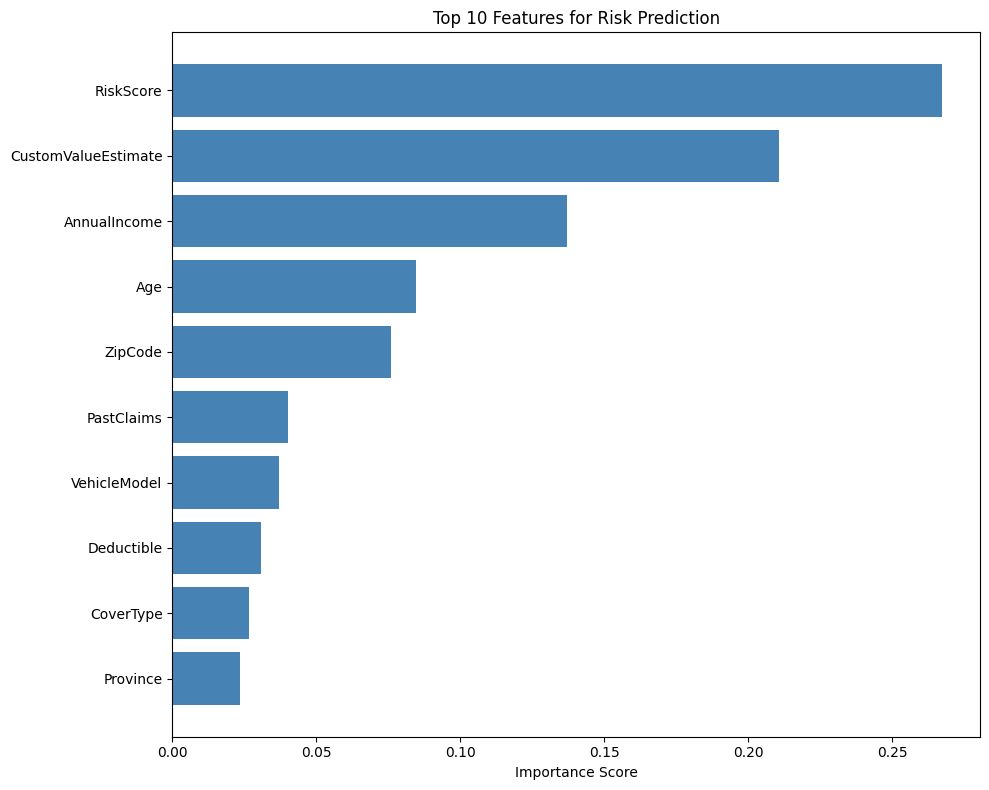

In [7]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Use the best model for interpretation
best_rf = rf if len(df_claims) > 0 else rf_clf

# Calculate feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features for Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
print("="*60)
print("RISK-BASED PRICING FRAMEWORK")
print("="*60)

# Calculate base metrics
avg_premium = df['TotalPremium'].mean()
avg_claim = df['TotalClaims'].mean()
claim_probability = df['Claimed'].mean()
expense_loading = 0.25  # 25% for operational costs
profit_margin = 0.10    # 10% target profit

# Calculate risk-adjusted premium
risk_adjusted_premium = (claim_probability * avg_claim) * (1 + expense_loading) * (1 + profit_margin)

print(f"Average Current Premium: {avg_premium:.2f}")
print(f"Average Claim Amount: {avg_claim:.2f}")
print(f"Claim Probability: {claim_probability:.2%}")
print(f"Expense Loading: {expense_loading:.0%}")
print(f"Target Profit Margin: {profit_margin:.0%}")
print(f"\n💰 Recommended Risk-Adjusted Premium: {risk_adjusted_premium:.2f}")

# Premium adjustment by risk score
print("\n" + "="*60)
print("PREMIUM ADJUSTMENT BY RISK SCORE")
print("="*60)

risk_quantiles = df['RiskScore'].quantile([0.25, 0.5, 0.75])
base_premium = risk_adjusted_premium

for quantile, risk_score in risk_quantiles.items():
    risk_factor = risk_score / df['RiskScore'].mean()
    adjusted_premium = base_premium * risk_factor
    print(f"Risk Score at {int(quantile*100)}th percentile ({risk_score:.1f}): Adjusted Premium = {adjusted_premium:.2f}")

RISK-BASED PRICING FRAMEWORK
Average Current Premium: 2488.13
Average Claim Amount: 1314.19
Claim Probability: 15.35%
Expense Loading: 25%
Target Profit Margin: 10%

💰 Recommended Risk-Adjusted Premium: 277.38

PREMIUM ADJUSTMENT BY RISK SCORE
Risk Score at 25th percentile (48.0): Adjusted Premium = 229.00
Risk Score at 50th percentile (57.0): Adjusted Premium = 271.94
Risk Score at 75th percentile (67.0): Adjusted Premium = 319.65
